# Geometric Dot Product

*Course notes for **Math for Machine Learning**, C1 · W3 · L1 · V07 — "Geometric Dot Product" (DeepLearning.AI).*

The dot product isn't just an algebraic sum of products — it encodes the **angle** between two vectors. This lecture covers:

- **Orthogonality:** two vectors are perpendicular iff their dot product is $0$.
- The **geometric formula** $u \cdot v = \|u\|\,\|v\|\cos\theta$ and the **projection** picture.
- What the **sign** of the dot product tells you about *which side* of a vector another vector lies on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Orthogonal vectors have dot product zero

Take the two perpendicular (**orthogonal**) vectors $(-1, 3)$ and $(6, 2)$. Their dot product is

$$ (-1)(6) + (3)(2) = -6 + 6 = 0. $$

This is a rule, not a coincidence:

$$ \boxed{\;u \perp v \quad\Longleftrightarrow\quad u \cdot v = 0\;} $$

**Recap** from the previous video: a vector dotted with **itself** is its norm squared, $v \cdot v = \|v\|^2$.

In [2]:
a = np.array([-1, 3])
b = np.array([6, 2])
print('a . b =', a @ b, '  -> orthogonal' if a @ b == 0 else '')
print('b . b =', b @ b, ' = ||b||^2 =', np.linalg.norm(b)**2)

a . b = 0   -> orthogonal
b . b = 40  = ||b||^2 = 40.00000000000001


## 2. The geometric formula

How does the dot product behave for two *general* vectors $u$ and $v$ separated by an angle $\theta$?

- $v \cdot v = \|v\|\,\|v\|$ (a vector with itself).
- For a longer vector in the **same direction**, it's just the product of the norms $\|u\|\,\|v\|$.
- With an **angle** in between, you first **perpendicularly project** one vector onto the other. If $u'$ is the projection of $u$ onto $v$, then $u \cdot v = \|u'\|\,\|v\|$. (It doesn't matter which you project onto which — the answer is the same.)

This is captured compactly by:

$$ \boxed{\; u \cdot v = \|u\|\,\|v\|\cos\theta \;} $$

and, rearranged, gives the **angle** between two vectors:

$$ \cos\theta = \frac{u \cdot v}{\|u\|\,\|v\|}. $$

In [3]:
def angle_between(u, v, degrees=True):
    cos_t = (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))
    cos_t = np.clip(cos_t, -1.0, 1.0)   # guard against tiny numerical overshoot
    t = np.arccos(cos_t)
    return np.degrees(t) if degrees else t

u = np.array([4, 0])
v = np.array([3, 3])
print('u . v                    =', u @ v)
print('||u|| ||v|| cos(theta)   =', round(np.linalg.norm(u)*np.linalg.norm(v)*np.cos(np.radians(45)), 3))
print('angle between u and v    =', round(angle_between(u, v), 2), 'degrees')

u . v                    = 12
||u|| ||v|| cos(theta)   = 12.0
angle between u and v    = 45.0 degrees


## 3. The sign of the dot product

Because $\cos\theta$ is positive for $\theta < 90^\circ$, zero at $90^\circ$, and negative for $\theta > 90^\circ$, the **sign** of the dot product tells you which side of a vector another vector lies on. Fixing $u = (6, 2)$:

| Vector | $u \cdot v$ | Meaning |
|---|---|---|
| $(-1, 3)$ | $0$ | **perpendicular** to $u$ |
| $(2, 4)$ | $+20$ | on the **same side** as $u$ (projection has positive length) |
| $(-4, 1)$ | $-22$ | on the **opposite side** (projection points against $u$) |

In general the plane splits into three regions relative to $u$: the perpendicular line ($u \cdot v = 0$), the **positive** half-plane, and the **negative** half-plane.

In [4]:
u = np.array([6, 2])
for v in [np.array([-1, 3]), np.array([2, 4]), np.array([-4, 1])]:
    dp = u @ v
    sign = 'zero (perpendicular)' if dp == 0 else ('positive' if dp > 0 else 'negative')
    print(f'u . {v} = {dp:>4}   -> {sign}')

u . [-1  3] =    0   -> zero (perpendicular)
u . [2 4] =   20   -> positive
u . [-4  1] =  -22   -> negative


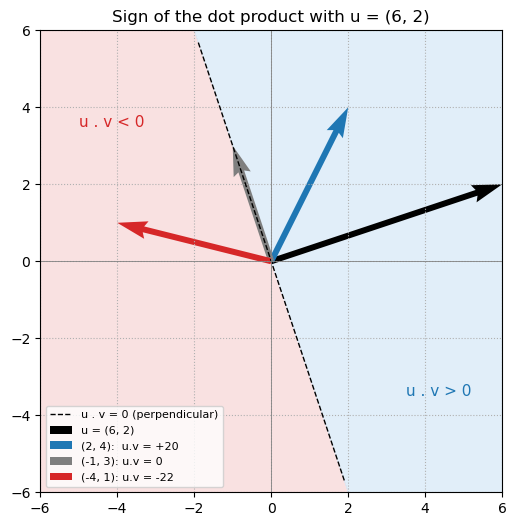

In [5]:
# Visualize the positive / negative / zero regions relative to u = (6, 2)
u = np.array([6, 2])

fig, ax = plt.subplots(figsize=(6, 6))

# shade half-planes: sign of (u . point) over a grid
lim = 6
gx, gy = np.meshgrid(np.linspace(-lim, lim, 400), np.linspace(-lim, lim, 400))
region = u[0]*gx + u[1]*gy   # dot product of u with each grid point
ax.contourf(gx, gy, region, levels=[-1e9, 0, 1e9], colors=['#f7d5d5', '#d5e8f7'], alpha=0.7)

# perpendicular line (u . x = 0): direction (-2, 6) ~ (-1, 3)
perp = np.array([-u[1], u[0]], dtype=float)
perp = perp / np.linalg.norm(perp) * lim
ax.plot([-perp[0], perp[0]], [-perp[1], perp[1]], 'k--', lw=1, label='u . v = 0 (perpendicular)')

opts = dict(angles='xy', scale_units='xy', scale=1, width=0.013)
ax.quiver(0, 0, u[0], u[1], color='k', **opts, label='u = (6, 2)')
ax.quiver(0, 0, 2, 4,  color='C0', **opts, label='(2, 4):  u.v = +20')
ax.quiver(0, 0, -1, 3, color='C7', **opts, label='(-1, 3): u.v = 0')
ax.quiver(0, 0, -4, 1, color='C3', **opts, label='(-4, 1): u.v = -22')

ax.text(3.5, -3.5, 'u . v > 0', color='C0', fontsize=11)
ax.text(-5, 3.5, 'u . v < 0', color='C3', fontsize=11)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':')
ax.legend(loc='lower left', fontsize=8)
ax.set_title('Sign of the dot product with u = (6, 2)')
plt.show()

## Summary

- **Orthogonality:** $u \perp v \iff u \cdot v = 0$.
- **Geometric formula:** $u \cdot v = \|u\|\,\|v\|\cos\theta$, so $\cos\theta = \dfrac{u \cdot v}{\|u\|\,\|v\|}$ recovers the angle. Geometrically it's the **projection** of one vector onto the other times the other's length.
- **Sign** of $u \cdot v$ tells you the side: **$> 0$** same side / acute angle, **$= 0$** perpendicular, **$< 0$** opposite side / obtuse angle — splitting the plane into a positive and a negative half-plane.